## Support Vector Machine (Yanran)

In [22]:
import pandas as pd
import numpy as np

In [23]:
df = pd.read_csv('MergedData_clean.csv')

df.head()

,Participant,ID,Gender,Group,Race,Ethnicity,Assmnt,Avg_Daily_Week_Min,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,...,Age,BMI,RRV_Pgoal,RRV_Agoal,RRVscore,RRVch,oesPos,oesNeg,pretieqPref,pretieqTole
0,407-0001,1,M,0.0,White,Not Hispanic or Latino,baseline,910.0,629.0,256.0,...,32.0,32.5,ellip,read,0.50,0.00,90.0,3.33,30.0,24.0
1,407-0001,1,M,0.0,White,Not Hispanic or Latino,endposttr,824.0,521.0,252.0,...,33.0,31.7,tmill,read,1.00,0.50,91.0,13.33,32.0,23.0
2,407-0001,1,M,0.0,White,Not Hispanic or Latino,pstwash,848.0,579.0,229.0,...,33.0,32.2,tmill,read,0.75,0.25,90.5,8.33,30.0,39.0
3,407-0002,2,M,0.0,White,Not Hispanic or Latino,baseline,680.0,546.0,127.0,...,33.0,32.1,cycle,wrdgms,0.00,0.00,83.0,48.33,26.0,20.0
4,407-0002,2,M,0.0,White,Not Hispanic or Latino,endposttr,622.0,510.0,102.0,...,33.0,32.0,ellip,cwrdpz,0.00,0.00,71.0,46.17,23.0,19.0


In [24]:
df["RRV_label"] = (df["RRVch"] > 0).astype(int)

baseline = df[df["Assmnt"] == "baseline"][["ID", "RRVscore"]]
baseline = baseline.rename(columns={"RRVscore": "Baseline_RRVscore"})
post = df[df["Assmnt"].isin(["pstwash", "endposttr"])]
merged = post.merge(baseline, on="ID", how="left")

df = merged
df.drop(columns=[])
df.dropna(subset=["Baseline_RRVscore"])

df["Assmnt"] = df["Assmnt"].map({
    "endposttr": 6,
    "pstwash": 10
})

df = df[df["ID"] != 25]

df = df.drop(columns = ['RRVscore','RRV_Pgoal','RRV_Agoal','Gender','Group','Height','Age','BMI','Participant','ID','Race','Ethnicity','Avg_Daily_Week_Min','RRVch','oesPos', 'oesNeg', 'pretieqPref', 'pretieqTole'])
df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


In [25]:
from sklearn.preprocessing import MinMaxScaler

svm_df = df.copy()
svm_df.dropna(subset=["Baseline_RRVscore"])

attr = svm_df.drop(columns = ['RRV_label'])
target = svm_df['RRV_label']
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,0.50
1,10,579.0,229.0,40.0,0.0,0.0,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0.75


In [26]:
scaler = MinMaxScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,0.0,0.277690,0.585714,0.783333,0.571429,0.0,0.50
1,1.0,0.323576,0.530952,0.666667,0.000000,0.0,0.50
2,0.0,0.268987,0.228571,0.183333,0.000000,0.0,0.00
3,1.0,0.276108,0.264286,0.083333,0.000000,0.0,0.00
4,1.0,0.208861,0.700000,0.300000,0.000000,0.0,0.75


In [27]:
from sklearn.model_selection import train_test_split

attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size = 0.3, shuffle = True)
target_train.head()
attr_train.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
22,1.0,0.168513,0.283333,0.166667,0.0,0.0,0.555556
119,0.0,0.876582,0.352381,0.116667,0.0,0.0,1.000000
96,1.0,0.782437,0.452381,0.483333,0.0,0.0,0.666667
65,0.0,0.064082,0.142857,0.350000,0.0,0.0,1.000000
9,0.0,0.340190,0.554762,0.500000,0.0,0.0,1.000000


In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_columns = ['Assmnt', 'Avg_Daily_Sed_Week_Min', 'Avg_Daily_Light_Week_Min',
					'Avg_Daily_Mod_Week_Min', 'Avg_Daily_Vig_Week_Min',
					'Avg_Daily_Very_Vig_Week_Min', 'Baseline_RRVscore']
attr_test_clean = attr_test[feature_columns]
svc = SVC()
svc.fit(attr_train, target_train)
target_pred_svm = svc.predict(attr_test_clean)

print('Model accuracy score with default hyperparameters: {0:0.4f}'.format(accuracy_score(target_test, target_pred_svm)))
print()
print('Classification Report')
print(classification_report(target_test, target_pred_svm))
print()
print('Confusion Matrix')
print(confusion_matrix(target_test, target_pred_svm))

Model accuracy score with default hyperparameters: 0.7568

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.96      0.83        23
           1       0.86      0.43      0.57        14

    accuracy                           0.76        37
   macro avg       0.80      0.69      0.70        37
weighted avg       0.78      0.76      0.73        37


Confusion Matrix
[[22  1]
 [ 8  6]]


[Text(0, 0.5, '0(No_Increase)'), Text(0, 1.5, '1(Increase_Motiv)')]

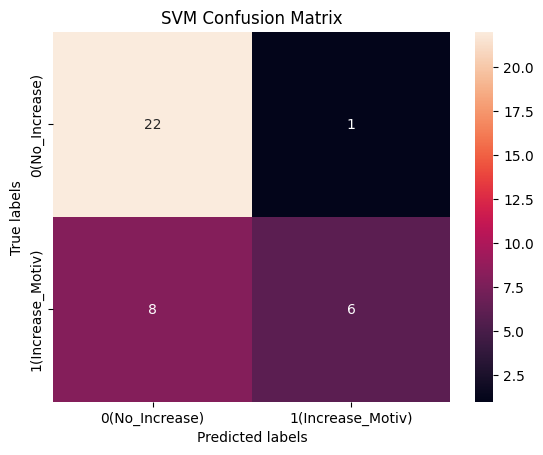

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(target_test, target_pred_svm)
ax = plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('SVM Confusion Matrix')
ax.xaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])
ax.yaxis.set_ticklabels(['0(No_Increase)', '1(Increase_Motiv)'])